In [16]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [17]:
transform = transforms.Compose([
    transforms.Pad(4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [18]:
dataset = CIFAR10(root='cifar10', train=True, download=True,
                                       transform=transform)

config = {'num_epochs': 10, 'lr': 0.01, 'batch_size': 128, 'test_size': 0.2}

In [20]:
indices = list(range(len(dataset)))
train_idx, val_idx = train_test_split(indices,
                 test_size=config['test_size'], shuffle=True, random_state=67)
train_dataset = Subset(dataset, train_idx)

val_dataset = Subset(dataset, val_idx)

val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

test_dataset = CIFAR10(root='cifar10', train=False,
                        download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

In [21]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [22]:
train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)

Посмотрим как выглядит семпл

In [23]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([128, 3, 32, 32])

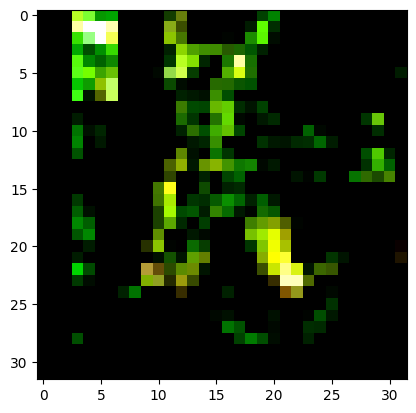

In [25]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [26]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [27]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([128, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [41]:
class Trainer:
    def __init__(self, config, transform=None, model=None):
        self.config = config
        self.transform = transform
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        self.model = (model if model is not None else BasicCNN()).to(self.device)
        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()
        self.setup_dataloaders()

        self.history = {'train_loss': [], 'train_acc': [],
                        'val_loss': [], 'val_acc': []}

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            print(f"Epoch {epoch+1}/{self.config['num_epochs']}: "
                  f"train_loss={train_loss:.4f}, train_acc={train_acc:.1f}%, "
                  f"val_loss={val_loss:.4f}, val_acc={val_acc:.1f}%")
        test_loss, test_acc = self.test()
        print(f"Test loss={test_loss:.4f}, test_acc={test_acc:.1f}%")

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [29]:
trainer_cnn = Trainer(config, transform=transform, model=BasicCNN())
trainer_cnn.run()

100%|██████████| 79/79 [00:04<00:00, 19.58it/s]


Epoch 1/10: train_loss=1.8006, train_acc=32.7%, val_loss=1.5955, val_acc=40.5%


100%|██████████| 79/79 [00:03<00:00, 19.85it/s]


Epoch 2/10: train_loss=1.5879, train_acc=41.7%, val_loss=1.5398, val_acc=43.1%


100%|██████████| 79/79 [00:04<00:00, 17.97it/s]


...

Epoch 9/10: train_loss=1.2739, train_acc=53.5%, val_loss=1.2796, val_acc=53.3%


100%|██████████| 79/79 [00:04<00:00, 19.58it/s]


Epoch 10/10: train_loss=1.2605, train_acc=53.9%, val_loss=1.2718, val_acc=53.4%


100%|██████████| 79/79 [00:04<00:00, 19.30it/s]

Test loss=1.2700, test_acc=53.6%


# ResNet-18

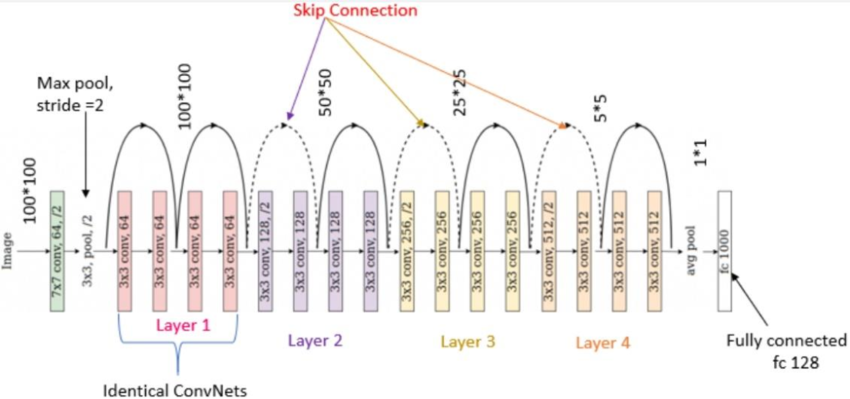

In [32]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

In [37]:
class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7,
                               stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = []
        layers.append(ResNetBlock(self.in_channels, out_channels,
                                  stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResNetBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [ ]:
# Запустить Trainer с ResNet18 на 10 эпох и сранивать графики train / val / test точности с базовой CNN

In [39]:
trainer_resnet = Trainer(config, transform=transform, model=ResNet(num_classes=10))
trainer_resnet.run()

100%|██████████| 79/79 [00:04<00:00, 17.17it/s]


Epoch 1/10: train_loss=1.9537, train_acc=31.3%, val_loss=2.0299, val_acc=35.8%


100%|██████████| 79/79 [00:05<00:00, 14.95it/s]


Epoch 2/10: train_loss=1.5803, train_acc=42.0%, val_loss=1.4759, val_acc=45.6%


100%|██████████| 79/79 [00:04<00:00, 16.21it/s]


...

Epoch 9/10: train_loss=0.7784, train_acc=72.2%, val_loss=0.8019, val_acc=72.2%


100%|██████████| 79/79 [00:05<00:00, 15.03it/s]


Epoch 10/10: train_loss=0.7540, train_acc=73.3%, val_loss=0.7824, val_acc=72.6%


100%|██████████| 79/79 [00:04<00:00, 16.52it/s]

Test loss=0.7867, test_acc=72.4%


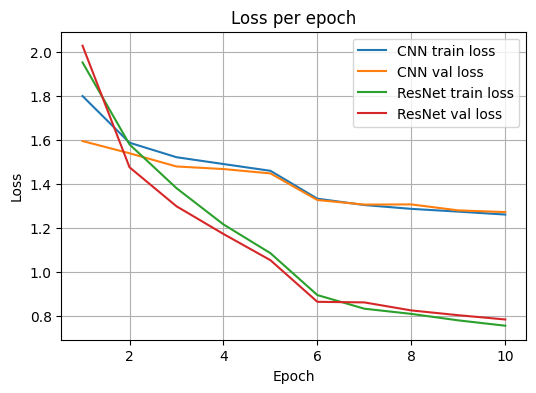

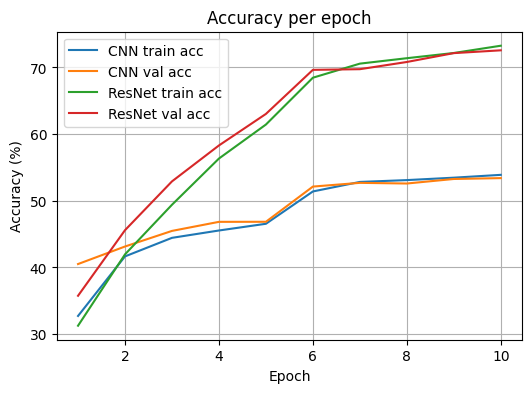

In [40]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(trainer_cnn.history['train_loss'])+1))

plt.figure(figsize=(6,4))
plt.plot(epochs, trainer_cnn.history['train_loss'], label='CNN train loss')
plt.plot(epochs, trainer_cnn.history['val_loss'],   label='CNN val loss')
plt.plot(epochs, trainer_resnet.history['train_loss'], label='ResNet train loss')
plt.plot(epochs, trainer_resnet.history['val_loss'],   label='ResNet val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss per epoch')
plt.legend(); plt.grid(True)
plt.savefig('loss_comparison.png')
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs, trainer_cnn.history['train_acc'], label='CNN train acc')
plt.plot(epochs, trainer_cnn.history['val_acc'],   label='CNN val acc')
plt.plot(epochs, trainer_resnet.history['train_acc'], label='ResNet train acc')
plt.plot(epochs, trainer_resnet.history['val_acc'],   label='ResNet val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title('Accuracy per epoch')
plt.legend(); plt.grid(True)
plt.savefig('acc_comparison.png')
plt.show()

ResNet значительно точнее обычной CNN (72% против 53%) и гораздо быстрее увеличивает точность на первых эпохах (может вырасти до 15% за одну эпоху, когда обычная CNN прибавляет не более 5%), но само обучение занимает немного больше времени.